# Sentiment-Augmented Technical Analysis and Forecasting of the S&P 500 (CME ES1 Futures)

- **Module:** 7CS084/UZ2: Applying Artificial Intelligence
- **Author:** Santiago Cruz | **ID:** 2584023
- **Dataset:** CME E-mini S&P 500 Futures (`ES1`), Daily Bars
- **Sentiment source:** CNN Fear & Greed Index

---

## Abstract

This report develops an end-to-end artificial intelligence pipeline that forecasts the short-horizon direction and
return of the S&P 500 E-mini futures contract (CME: ES1) by fusing classical technical analysis with market
sentiment. Daily OHLC price data is enriched with momentum, trend and volatility indicators (RSI, MACD, Bollinger
Bands, ATR) and merged with CNN's Fear & Greed Index, a seven-factor composite gauge of investor sentiment. The
system is framed as an intelligent perception-reasoning-action agent: a propositional rule engine and a Gaussian
Hidden Markov Model provide interpretable, probabilistic reasoning layers; a computer-vision module extracts
trendlines and pivots directly from rendered price charts; and tree-based classifiers plus a Bidirectional LSTM
provide the learned prediction layer. All learned components are benchmarked against a majority-class baseline
under strictly time-ordered validation. The project demonstrates how symbolic reasoning, probabilistic graphical
models, computer vision and deep sequence modelling combine into one coherent financial-forecasting architecture.

## Problem Statement

Short-horizon equity-index prediction is a canonical hard problem in applied AI: markets are close to (but not
perfectly) efficient, so any exploitable structure is weak, non-stationary and easily confounded with noise.
Classical **technical analysis** assumes that price/volume patterns partially recur and can be summarised by
indicators such as RSI, MACD and Bollinger Bands. **Behavioural finance** adds a complementary hypothesis: crowd
sentiment — measured here by CNN's *Fear & Greed Index* (FGI) — captures collective over-reaction (extreme fear or
extreme greed) that tends to partially mean-revert, independently of what the price series alone encodes.

**Problem.** Given the daily OHLC history of ES1 and the daily CNN Fear & Greed Index, (a) predict the *direction*
of the next trading day's close (a binary classification problem) and (b) forecast the *magnitude* of the next-day
return (a regression/sequence-modelling problem), using a pipeline that is explainable at every stage rather than a
single opaque model.

**Approach.** The project is deliberately framed as an **intelligent agent** (Week 1 — PEAS):

- **Percepts (sensors):** daily OHLC bars (`CME_ES1_1D.csv`) and the daily CNN Fear & Greed Index (fetched live, or
  loaded from a local cache / offline proxy — Section 2).
- **Environment:** the S&P 500 futures market — *partially observable* (true drivers of price are hidden),
  *stochastic*, *sequential*, *dynamic* (evolves whether or not the agent acts) and *continuous* in price/time.
- **Reasoning:** a propositional production-rule engine (Week 2) and a Gaussian Hidden Markov Model over
  return/volatility (Week 4) turn raw percepts into interpretable intermediate beliefs (signal, regime).
- **Learning / Actuators:** tree-based classifiers and a Bidirectional LSTM turn engineered features + beliefs into
  a next-day direction / return forecast — the agent's "action" in this offline research setting is the forecast
  itself, rather than a live order.
- **Performance measure:** classification accuracy/F1/MCC against a majority-class baseline, and RMSE/MAE/
  directional accuracy for the return regressor, all evaluated on a strictly held-out, chronologically later slice
  of data (no shuffling, no lookahead).

The scope is intentionally limited to *forecasting*, not live trading: transaction costs, slippage, execution
latency and position sizing are out of scope and are discussed as future work in the Suggestions section.

## Literature Review

**Sentiment and the CNN Fear & Greed Index.** Farrell & O'Connor (2024) test whether the CNN Fear & Greed Index
Granger-causes returns on the S&P 500, Nasdaq Composite and Russell 3000. They find significant predictive power
over 2011–2020, a weaker but still present effect over 2021–2024, and — notably — that the FGI outperforms the VIX
alone as a predictor of equity returns, which motivates using the *composite* FGI rather than a single volatility
proxy as the sentiment feature in this project [2]. CNN's own methodology page documents the index as an unweighted
average of seven sub-indicators (momentum, price strength, price breadth, put/call ratio, junk-bond demand, safe-
haven demand and volatility), each rescaled to 0–100 [1]. Critically, Farrell & O'Connor's own weakening-effect
finding is double-edged: it could reflect genuine regime change (post-2020 QE-driven markets behave differently),
or it could reflect a Goodhart's-law-style effect in which a *publicly broadcast* sentiment index gets partially
arbitraged away once it becomes popular enough to influence the crowd it measures. Neither this project nor the
cited paper can distinguish between those explanations from price data alone, which is precisely why Section 13
below treats `fgi_score`/`fgi_zscore` as features to be *empirically ranked* by Random Forest feature importance
rather than assumed a priori to be predictive — an explicit design response to this open question in the
literature, not just a citation of it.

**Deep learning for price prediction.** Fischer & Krauss (2018) remain a benchmark reference for applying LSTM
networks to next-day directional prediction of S&P 500 constituents (1992–2015), reporting ~56% daily directional
accuracy and statistically significant risk-adjusted returns after costs, and showing LSTMs outperforming SVM and
Random Forest baselines on the same task [3] — directly motivating both the tree-ensemble baselines and the
Bidirectional LSTM implemented below. However, a 2024 systematic literature review of the field is critical of how
that kind of result is usually reported: across the studies it surveys, methodology is frequently non-standardised
— heterogeneous datasets, inconsistent evaluation metrics and inconsistent baselines make cross-paper comparison
unreliable, and a majority of studies report only raw accuracy without a discriminatory metric such as MCC or a
naive baseline for context [13]. This project takes that critique as a direct methodological constraint rather
than a passing remark: every classifier in Section 11 is benchmarked against an explicit `DummyClassifier`
majority-class floor, evaluated with `balanced_accuracy`/F1/MCC (not accuracy alone) under `TimeSeriesSplit`
walk-forward validation, and never on a randomly shuffled split — addressing three of the specific weaknesses [13]
identifies in the wider literature.

**Fusing sentiment with sequence models.** More recent work moves beyond price-only LSTMs by fusing text-derived
sentiment with recurrent architectures: a Bi-LSTM + RoBERTa model with Bahdanau attention outperforms MLP and plain
LSTM baselines on stock-price prediction [4], and financial-news sentiment coupled with LSTM has been shown to
produce more *explainable* price forecasts than price-only models [5]. This project follows the same fusion
principle but substitutes the (already-aggregated, numeric) CNN Fear & Greed Index for raw news text, trading some
of the richness of free text (topic, entity, intensity) for a well-defined, low-latency, low-compute daily signal —
a deliberate scope decision discussed further under Suggestions & Improvements, where NLP-based sentiment fusion is
proposed as the next iteration rather than the current one.

**Computer vision on price charts.** Financial Innovation (2020) shows that *encoding candlesticks as images* and
classifying them with CNNs is a viable alternative to hand-crafted indicators [6], and a 2025 arXiv study confirms
CNNs on candlestick-chart images can predict short-term market strength [7]. Both papers motivate treating a price
chart as an image rather than only as a numeric series; Section 10 of this notebook implements the classical
(pre-deep-learning) end of that spectrum — Canny edge detection and the Hough transform for trendlines, Harris
corners for pivots — as an explainable complement to the learned models, in line with the Week 5 syllabus. This is
a deliberate trade-off worth stating plainly: [6] and [7] report that a learned 2D-CNN on chart images typically
out-performs classical edge/corner detectors for *predictive* pattern classification, so the CV module here is
scoped as a transparent, zero-training-cost diagnostic layer rather than a claim that it rivals a trained CNN —
the commercial-implementation discussion below and the Suggestions section return to this distinction.

**Regime detection with HMMs.** Yuan & Mitra (2019) and later hierarchical-HMM work (arXiv:2007.14874) show that
Gaussian Hidden Markov Models fit on return/volatility series recover interpretable bull/bear/high-volatility
regimes without any labelled data, and that conditioning trading decisions on the decoded regime can improve
risk-adjusted performance [8, 9]. Section 6 applies the same idea as an unsupervised, probabilistic feature for the
downstream classifiers.

**Sequence models beyond the LSTM.** Lim et al. (2021) introduce the Temporal Fusion Transformer (TFT), an
attention-based architecture that has become a de-facto state-of-the-art reference for interpretable multi-horizon
time-series forecasting, and subsequent work has applied TFT variants specifically to financial return prediction
[12]. This project deliberately implements a Bidirectional LSTM rather than a TFT in Section 12: the LSTM is a
better-understood, lower-parameter-count architecture appropriate for the dataset size here (roughly 6,000 daily
bars), whereas a full TFT is designed for larger, multi-horizon, multi-entity panels and would be under-constrained
on a single instrument's daily series. The gap to [12] is treated as a scoped limitation rather than an oversight,
and is picked up explicitly in the Suggestions & Improvements section.

**Data engineering note.** CNN does not publish an official Fear & Greed Index API; the endpoint used in Section 2
(`production.dataviz.cnn.io/index/fearandgreed/graphdata`) is undocumented and has been reverse-engineered by the
community [10, 11]. This is treated explicitly as a data-reliability risk in the Suggestions section, and is also
contrasted against how commercial vendors solve the same problem contractually rather than by reverse-engineering
an endpoint — see Commercial Implementations & Features, below.

## Architecture

### 1. System block diagram

Figure 1 below is an original diagram (generated programmatically with Matplotlib, not reproduced from any third
party) showing the full pipeline implemented across the 13 code sections of this notebook: two perception feeds,
an interpretable reasoning layer (propositional rules + Gaussian HMM), a dual learning layer (tree ensembles +
Bidirectional LSTM), a unified evaluation stage, and a diagnostic-only computer-vision branch that never touches
the learned models.

![Figure 1 — System architecture block diagram](figures/architecture_block_diagram.png)

A plain-text equivalent of the same flow is given below for quick reference when viewing the notebook in an
environment without image rendering:

```
                 ┌───────────────────────────┐        ┌──────────────────────────────┐
                 │  CME ES1 daily OHLC (CSV) │        │ CNN Fear & Greed Index (API) │
                 │  1999 – present           │        │ live fetch → local CSV cache │
                 └─────────────┬─────────────┘        │ → offline proxy fallback     │
                               │                      └───────────────┬──────────────┘
                               │        PERCEPTION                    │
                               └───────────────┬──────────────────────┘
                                               ▼
                          ┌───────────────────────────────────────┐
                          │ Technical + Sentiment Feature Engine  │
                          │ RSI · MACD · Bollinger · ATR · lags   │
                          │ returns/volatility · FGI z-score      │
                          └─────────────────┬─────────────────────┘
                                            ▼
                ┌───────────────────────────────────────────────────┐
                │             REASONING LAYER (interpretable)       │
                │  ┌───────────────────────┐   ┌─────────────────┐  │
                │  │ Propositional rule    │   │ Gaussian HMM    │  │
                │  │ engine (Week 2)       │   │ regime detector │  │
                │  │ IF RSI/MACD/FGI THEN  │   │                 │  │
                │  └───────────┬───────────┘   └────────┬────────┘  │
                └──────────────┼────────────────────────┼───────────┘
                               ▼                        ▼
                    ┌───────────────────────────────────────────┐
                    │               LEARNING LAYER              │
                    │ DummyClassifier → DecisionTree → RandomF. │
                    │ (GridSearchCV + TimeSeriesSplit search)   │
                    │ Bidirectional LSTM (windowed sequences)   │
                    └───────────────────┬───────────────────────┘
                                        ▼
                    ┌───────────────────────────────────────────┐
                    │  ACTION / OUTPUT: next-day direction &    │
                    │  next-day return forecast + explanations  │
                    └───────────────────┬───────────────────────┘
                                        ▼
                    ┌───────────────────────────────────────────┐
                    │       EVALUATION (held-out, time-ordered) │
                    │ Accuracy/F1/MCC · RMSE/MAE/Dir.Accuracy   │
                    └───────────────────────────────────────────┘

   (parallel, diagnostic-only branch)
                    ┌───────────────────────────────────────────┐
                    │  Computer-Vision trendline/pivot detector │
                    │  Canny edges → Hough transform → Harris   │
                    │  corners (Week 5), rendered from price    │
                    │  chart images — explainability layer      │
                    └───────────────────────────────────────────┘
```

### 2. PEAS specification (Week 1)

| Element | Description |
|---|---|
| **Performance measure** | Accuracy / balanced accuracy / F1 / MCC (classifier); RMSE / MAE / directional accuracy (regressor); interpretability of the rule/HMM layers |
| **Environment** | S&P 500 futures market: partially observable, stochastic, sequential, dynamic, continuous |
| **Actuators** | Emits a forecast (direction label + return estimate) and an explanation (rule fired, HMM regime, feature importance) |
| **Sensors** | Daily OHLC feed (CSV/exchange), CNN Fear & Greed Index feed (API/cache/proxy) |

Figure 2 renders the same PEAS specification as the classical sense-agent-act control loop from the Week 1
syllabus, making explicit that the "agent" in this project is the reasoning + learning stack as a whole, not any
single model:

![Figure 2 — PEAS agent loop](figures/peas_agent_loop.png)

### 3. Week → notebook-section map

| # | Section | Code Cell | Primary weekly topic | One-line summary |
|---|---|---|---|---|
| 1 | Environment & Reproducibility | 1/13 | Week 1 – agent tooling | Imports, seeds, optional CV/HMM dependency guards |
| 2 | Technical Price Data Ingestion | 2/13 | Week 1 – perception/sensors | Loads & cleans CME ES1 daily OHLC |
| 3 | Sentiment Data Acquisition | 3/13 | Behavioural-finance sentiment | Fetches/caches CNN Fear & Greed Index, offline proxy fallback |
| 4 | Technical Indicator Engineering | 4/13 | Technical analysis core | RSI, MACD, Bollinger, ATR, returns, sentiment merge |
| 5 | Rule-Based Reasoning | 5/13 | Week 2 – knowledge representation | Propositional IF-THEN production system |
| 6 | HMM Regime Detection | 6/13 | Week 4 – HMM & Bayesian nets | Gaussian HMM latent bull/bear/high-vol states |
| 7 | Modelling Dataset Assembly | 7/13 | — | Finalises `df_model`, `X_bl`, `X_fe`, `y` |
| 8 | Descriptive Statistics & Stationarity | 8/13 | Statistical foundation | Skew/kurtosis/outliers, ADF test |
| 9 | Visual Analytics | 9/13 | — | Price/FGI overlay, correlation heatmap, seasonality |
| 10 | CV Trendline & Pivot Detection | 10/13 | Week 5 – computer vision | Canny edges, Hough transform, Harris corners |
| 11 | Baseline & Tree Classifiers | 11/13 | Week 3 – search (GridSearchCV) | Dummy/Decision-Tree/Random-Forest tuned via `TimeSeriesSplit` |
| 12 | Sequence Windowing & BiLSTM | 12/13 | Week 6-7 – sequence modelling | Windowed Bidirectional LSTM next-day return regressor |
| 13 | Unified Evaluation | 13/13 | — | Metrics, confusion matrices, feature importance |

### 4. Software & hardware

- **Software:** Python 3.10, TensorFlow/Keras (`WLV-TF` conda kernel, `tensorflow[and-cuda]==2.15.*`), scikit-learn,
  statsmodels, pandas/NumPy, Matplotlib/Seaborn, OpenCV (`opencv-python`, optional — Section 10), `hmmlearn`
  (optional — Section 6), `requests` (Section 3).
- **Hardware:** classical ML cells (Sections 5, 7, 9, 11) run comfortably on CPU. The Bidirectional LSTM
  (Section 12) benefits from an NVIDIA CUDA-capable GPU for practical training times, per the GPU setup documented
  in the repository `README.md`.

## Commercial Implementations and Features

Every architectural pillar implemented in this notebook already has a commercial analogue operating at production
scale, which is a useful reality check on both the validity of the approach and the scope gap between a coursework
prototype and a deployed system. On the sentiment side, TrendSpider packages the same CNN Fear & Greed Index used
in Section 3 as a purchasable indicator that overlays directly onto a live chart, colour-coding the five sentiment
bands and mapping the single daily CNN reading forward across whatever intraday timeframe the trader is viewing
[14]. The existence of a commercial product built entirely around republishing this one index is itself evidence
that retail demand for a simple, interpretable sentiment gauge is real, which supports the choice made in Section 3
to use the FGI rather than a more exotic proprietary sentiment score; at the same time, TrendSpider inherits
exactly the data-reliability problem this project documents explicitly in Section 3 and the Suggestions section —
it depends on CNN continuing to serve the same undocumented endpoint indefinitely — and its approach to daily-to-
intraday alignment is considerably cruder than the explicit date-normalised join-and-forward-fill performed in
Section 4, since it simply extends the last known value without any calendar-aware reconciliation.

At the institutional end of the same sentiment-analysis pillar, RavenPack and MarketPsych operate at a completely
different order of magnitude: RavenPack alone is reported to be used by more than seventy percent of the best-
performing quantitative hedge funds and asset managers, recognises upward of twelve million named entities and
maintains a taxonomy of over seven thousand distinct event types drawn from global news, filings and social media
[15], while MarketPsych decomposes sentiment into psychologically grounded dimensions — fear, optimism, confusion,
urgency and joy — rather than a single scalar score, aggregated from several million finance-related articles a
day across dozens of languages [16]. Bloomberg has offered a comparable, if narrower, sentiment function on its
Terminal since 2010, scoring every news story about a company as positive, negative or neutral and averaging the
prior twenty-four hours into a single pre-market score that traders can act on directly [17]. Set against this
landscape, the single 0–100 composite figure pulled from CNN in Section 3 is a deliberately coarse approximation
of what these vendors sell as a service — it captures market-wide mood but none of the entity-level, topic-level or
emotion-level granularity that RavenPack and MarketPsych are valued for — and that gap is precisely the one the
Suggestions section proposes narrowing by fusing a FinBERT-style news-sentiment channel alongside the existing FGI
feature rather than replacing it.

On the technical-analysis and pattern-recognition pillar, Autochartist and Trading Central are embedded directly
into the trading platforms of numerous retail brokers, scanning markets continuously for classical chart patterns
— head-and-shoulders, channels, triangles, double tops — and Fibonacci-based setups, then pushing alerts to
end users without any manual charting effort [18]. Trade Ideas takes this further with its Holly AI engine, which
runs roughly seventy scanning strategies overnight, backtests each against the most recent market data, and
reportedly recognises well over a hundred candlestick and chart patterns at a claimed ninety-five percent
recognition accuracy, translating in third-party testing to real-world annualised returns in the order of fifteen
to twenty percent after trading friction [19]. Two caveats in that same reporting are instructive for this
project's own scope decisions: Holly's edge is concentrated in volatile small- and mid-cap names precisely because
they produce larger percentage moves, meaning its signals do not transfer cleanly to a liquid, large-cap index
future such as ES1; and real-world slippage on the more volatile names it favours has been observed to erode
twenty to forty percent of the strategy's theoretical return. Both points reinforce why the computer-vision module
in Section 10 of this notebook is deliberately scoped as a transparent, zero-cost diagnostic overlay rather than
marketed as a standalone alpha source — an explicit, considerably more modest claim than the one made by these
commercial pattern-recognition products.

The learning-layer pillar has its own commercial parallel in Numerai, a hedge fund built entirely from crowdsourced
machine-learning models: more than thirty thousand data scientists submit encrypted predictions weekly, upwards of
twelve hundred staked models are blended into a single meta-model, and the fund has recently closed a thirty-
million-dollar funding round at a five-hundred-million-dollar valuation with a commitment of up to five hundred
million dollars in additional capacity from J.P. Morgan Asset Management [20]. Numerai's meta-model is, in effect,
industrial-scale model ensembling — the same principle behind comparing a dummy baseline, a decision tree, a random
forest and a Bidirectional LSTM side by side in Sections 11 through 13 of this notebook, just applied across
thousands of independently developed models rather than four. That a fund built on this exact principle has
attracted institutional capital at this scale is meaningful evidence that no single model family is expected to
dominate market prediction, and that disciplined comparison across heterogeneous models — symbolic, probabilistic
and deep-learning alike, as implemented here — is closer to current best practice than betting on one architecture.

Read together, these five products validate each of this project's three pillars individually — sentiment
aggregation, automated technical pattern detection, and ensemble-style predictive modelling all have proven
commercial demand — but none of them combine an auditable propositional rule layer, an unsupervised probabilistic
regime detector, a classical computer-vision diagnostic and a deep sequence model inside one transparent pipeline
the way this notebook does; Holly AI's underlying strategy logic is not disclosed to its subscribers, and Bloomberg's
sentiment score is delivered as a raw research input rather than an integrated forecast. That combination of
interpretability and multi-layer reasoning, rather than raw predictive accuracy against any of these commercial
tools, is the specific contribution this project makes, and it is the axis along which the Suggestions and
Improvements section below proposes closing the remaining gap to production-grade practice.

## Section 1 — Environment & Reproducibility Setup

Establishes the software environment — the agent's "sensors and actuators" in the Week 1 PEAS framing — used by
every later section: data handling (NumPy/Pandas), visualisation (Matplotlib/Seaborn), classical ML
(scikit-learn), deep sequence modelling (TensorFlow/Keras), statistical diagnostics (statsmodels) and HTTP access
for the live sentiment feed (`requests`). Two research libraries used later — **OpenCV** (Section 10, Week 5 computer
vision) and **hmmlearn** (Section 6, Week 4 HMM) — are imported defensively behind `try/except` guards so the rest
of the notebook still runs, with a printed warning, if either is missing from the active kernel. A fixed
`RANDOM_STATE` is set for NumPy/TensorFlow to keep results reproducible across runs.

In [56]:
# ---------------------------------------------------------------------------
# Section 1 — Environment & Reproducibility Setup
# ---------------------------------------------------------------------------

import sys

print("OS Platform:", sys.platform)
print("Python version:", sys.version)
print("Conda Environment:", sys.prefix)    

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)
print("Seaborn version:", sns.__version__)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, LayerNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)

from statsmodels.tsa.stattools import adfuller

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef, cohen_kappa_score,
    log_loss, brier_score_loss, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve,
    mean_absolute_error, mean_squared_error
)

print("Scikit-learn version:", pd.__version__)
print("Statsmodels version:", pd.__version__)

# Powers the Canny edge detector, probabilistic Hough transform and Harris corner detector used in Section 10 to read trendlines/pivots directly off a rendered price-chart image.
try:
    import cv2
    CV2_AVAILABLE = True
    print("OpenCV version:", cv2.__version__)
except ImportError:
    CV2_AVAILABLE = False
    print("[warning] opencv-python not installed - Section 10 (CV trendline/pivot detection) will be skipped")

# Provides the Gaussian Hidden Markov Model used in Section 6 to infer latent bull / bear / high-volatility market regimes.
try:
    from hmmlearn.hmm import GaussianHMM
    HMMLEARN_AVAILABLE = True
except ImportError:
    HMMLEARN_AVAILABLE = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")

DATA_DIR = Path("/home/dev-algo/Documents/WLV-MSc-AI/05_Applying_Artificial_Intelligence")

OS Platform: linux
Python version: 3.10.19 (main, Oct 21 2025, 16:43:05) [GCC 11.2.0]
Conda Environment: /home/dev-algo/anaconda3/envs/WLV-TF
NumPy version: 1.26.4
Pandas version: 2.3.3
Matplotlib version: 3.10.8
Seaborn version: 0.13.2
TensorFlow version: 2.11.1
Scikit-learn version: 2.3.3
Statsmodels version: 2.3.3
OpenCV version: 5.0.0


## Section 2 — Technical Price Data Ingestion

Loads the raw `CME_ES1_1D.csv` file (daily OHLC bars for the S&P 500 E-mini futures continuous contract, plus
pre-computed moving averages `MA 9`/`MA 21` and exponential moving averages `EMA 55…350`). The source file is
nominally semicolon-delimited but the exported rows are in fact comma-separated within a single semicolon "column"
— the loader defends against both encodings, coerces the timestamp to UTC, drops unparsable/duplicate rows, and
sorts into a clean, time-indexed DataFrame. This is the **perception** stage of the agent (Week 1): everything
downstream is derived exclusively from this feed plus the sentiment feed loaded in Section 3.

In [57]:
# ---------------------------------------------------------------------------
# Section 2 — Technical Price Data Ingestion
# ---------------------------------------------------------------------------
csv_path = DATA_DIR / "CME_ES1_1D.csv"
if not csv_path.exists():
    raise FileNotFoundError(f"Dataset not found: {csv_path.resolve()}")

raw_df = pd.read_csv(csv_path, sep=";")
print("Raw shape:", raw_df.shape)
print("Raw columns:", list(raw_df.columns))

df = raw_df.copy()
# Defensive re-parse: some exports of this file land as one semicolon-delimited
# "column" whose values are actually comma-separated -> split it out explicitly.
if df.shape[1] == 1 and df.columns[0].startswith("time,"):
    df = df.iloc[:, 0].str.split(",", expand=True)
    df.columns = ["time", "open", "high", "low", "close", "MA 9", "MA 21", "EMA 55", "EMA 125", "EMA 200", "EMA 350"]

df["time"] = pd.to_datetime(df["time"], utc=True, errors="coerce")

invalid_ts = df["time"].isna().sum()
dup_count_before = df.duplicated().sum()

df = df.dropna(subset=["time"]).drop_duplicates().sort_values("time").set_index("time")

# OHLC must be numeric before any indicator/feature computation downstream.
for col in ["open", "high", "low", "close"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("\nInvalid timestamps removed:", invalid_ts)
print("Duplicate rows removed:", dup_count_before)
print("Final shape:", df.shape)
print("\nMissing values per column:\n", df.isna().sum())
print("\nData types:\n", df.dtypes)

Raw shape: (6944, 1)
Raw columns: ['time,open,high,low,close,MA 9,MA 21,EMA 55,EMA 125,EMA 200,EMA 350']

Invalid timestamps removed: 0
Duplicate rows removed: 0
Final shape: (6944, 10)

Missing values per column:
 open       0
high       0
low        0
close      0
MA 9       0
MA 21      0
EMA 55     0
EMA 125    0
EMA 200    0
EMA 350    0
dtype: int64

Data types:
 open       float64
high       float64
low        float64
close      float64
MA 9        object
MA 21       object
EMA 55      object
EMA 125     object
EMA 200     object
EMA 350     object
dtype: object


## Section 3 — Sentiment Data Acquisition: CNN Fear & Greed Index

Pulls the daily **CNN Fear & Greed Index** (FGI) — an unweighted 0–100 composite of seven market-sentiment
sub-indicators (momentum, price strength, price breadth, put/call ratio, junk-bond demand, safe-haven demand,
volatility) published by CNN Business [1]. There is no official public API; the function below targets the
community-reverse-engineered `dataviz.cnn.io` endpoint [10, 11]. Because this endpoint is undocumented and can
change or block programmatic access without notice, the acquisition strategy is layered for reproducibility and
resilience:

1. **Local cache** — if `fear_greed_index_cache.csv` already exists in this folder, load it directly (fast,
   network-free, fully reproducible).
2. **Live fetch** — otherwise attempt a live HTTP GET against the CNN dataviz endpoint and cache the result.
3. **Offline proxy fallback** — if both fail (e.g. no network access, endpoint blocked/changed), fall back to a
   deterministic, clearly-labelled proxy built from price momentum and inverse volatility — the same conceptual
   ingredients as two of CNN's seven real sub-indicators — purely so the rest of the pipeline can still run
   end-to-end. This proxy is *not* a substitute for the real index and is reported as such wherever it is used.

Source: CNN Business, "Fear and Greed Index – Investor Sentiment," https://www.cnn.com/markets/fear-and-greed [1].

In [58]:
# ---------------------------------------------------------------------------
# Section 3 — Sentiment Data Acquisition: CNN Fear & Greed Index
# ---------------------------------------------------------------------------
FGI_CACHE_PATH = DATA_DIR / "fear_greed_index_cache.csv"
# Community-documented (unofficial) CNN dataviz endpoint - see references [10], [11].
FGI_API_URL = "https://production.dataviz.cnn.io/index/fearandgreed/graphdata/2010-01-01"
FGI_HEADERS = {
    "User-Agent": ("Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                    "(KHTML, like Gecko) Chrome/124.0 Safari/537.36"),
    "Accept": "application/json",
}
FGI_BINS = [-0.01, 25, 45, 55, 75, 100.01]
FGI_LABELS = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]


def fetch_fear_greed_index(url=FGI_API_URL, headers=FGI_HEADERS, timeout=10):
    '''Pull the full CNN Fear & Greed Index history from CNN's public
    (undocumented) dataviz endpoint [10], [11].

    Returns a DataFrame indexed by UTC date with columns:
        fgi_score     - 0-100 composite sentiment score
        fgi_category  - Extreme Fear / Fear / Neutral / Greed / Extreme Greed

    Raises on any network/HTTP/parsing failure so the caller can fall back.
    '''
    resp = requests.get(url, headers=headers, timeout=timeout)
    resp.raise_for_status()
    payload = resp.json()
    hist = payload["fear_and_greed_historical"]["data"]

    fgi = pd.DataFrame(hist)
    fgi["time"] = pd.to_datetime(fgi["x"], unit="ms", utc=True)
    fgi = fgi.rename(columns={"y": "fgi_score"}).set_index("time")[["fgi_score"]]
    fgi["fgi_score"] = pd.to_numeric(fgi["fgi_score"], errors="coerce")
    fgi["fgi_category"] = pd.cut(fgi["fgi_score"], bins=FGI_BINS, labels=FGI_LABELS)
    return fgi.dropna(subset=["fgi_score"]).sort_index()


def synthetic_fear_greed_proxy(price_df):
    '''Deterministic, offline stand-in for the CNN Fear & Greed Index.

    NOT a substitute for the real index - used only for pipeline continuity
    when the network/API is unavailable (e.g. an offline grading
    environment). Builds a bounded 0-100 proxy from 5-day price momentum and
    20-day realised volatility, z-scored against their own trailing 1-year
    history - conceptually the "momentum" and "volatility" ingredients that
    also feed two of CNN's seven real sub-indicators [1].
    '''
    ret_5 = price_df["close"].pct_change(5)
    vol_20 = price_df["close"].pct_change().rolling(20).std()
    momentum_z = (ret_5 - ret_5.rolling(252).mean()) / ret_5.rolling(252).std()
    vol_z = (vol_20 - vol_20.rolling(252).mean()) / vol_20.rolling(252).std()

    raw_score = 50 + 15 * momentum_z.fillna(0) - 10 * vol_z.fillna(0)
    score = raw_score.clip(0, 100)

    out = pd.DataFrame({"fgi_score": score})
    out["fgi_category"] = pd.cut(out["fgi_score"], bins=FGI_BINS, labels=FGI_LABELS)
    return out


# --- Acquire, with local caching for reproducibility ------------------------
if FGI_CACHE_PATH.exists():
    fgi_df = pd.read_csv(FGI_CACHE_PATH, index_col=0, parse_dates=True)
    fgi_source = "local cache"
else:
    try:
        fgi_df = fetch_fear_greed_index()
        fgi_df.to_csv(FGI_CACHE_PATH)
        fgi_source = "CNN dataviz API (live)"
    except Exception as exc:
        print(f"[warning] Live CNN Fear & Greed fetch failed ({exc!r}); "
              f"falling back to a documented offline proxy - see Section 3 docstring.")
        fgi_df = synthetic_fear_greed_proxy(df)
        fgi_source = "synthetic proxy (offline fallback - NOT the real CNN index)"

print(f"Fear & Greed source: {fgi_source}")
print("FGI shape:", fgi_df.shape)
fgi_df.head()

[warning] Live CNN Fear & Greed fetch failed (HTTPError('500 Server Error: Internal Server Error for url: https://production.dataviz.cnn.io/index/fearandgreed/graphdata/2010-01-01')); falling back to a documented offline proxy - see Section 3 docstring.
Fear & Greed source: synthetic proxy (offline fallback - NOT the real CNN index)
FGI shape: (6944, 2)


,fgi_score,fgi_category
time,,
1999-01-28 00:00:00+00:00,50.0,Neutral
1999-01-29 00:00:00+00:00,50.0,Neutral
1999-02-01 00:00:00+00:00,50.0,Neutral
1999-02-02 00:00:00+00:00,50.0,Neutral
1999-02-03 00:00:00+00:00,50.0,Neutral


## Section 4 — Technical Indicator Engineering & Sentiment Fusion

Builds the full technical-analysis feature set on top of the cleaned OHLC series and fuses in the Section 3
sentiment feed. Indicators implemented from first principles (no external TA library, to keep the computation
transparent and auditable):

- **Momentum:** `rsi_14` — 14-period Relative Strength Index (Wilder smoothing via an exponential moving average).
- **Trend:** `macd`, `macd_signal`, `macd_hist` — 12/26/9 Moving Average Convergence/Divergence.
- **Volatility:** `bb_upper`/`bb_lower`/`bb_width` — 20-period, 2-sigma Bollinger Bands; `atr_14` — 14-period
  Average True Range.
- **Lags/returns:** 1/3/7-day lagged close, 1-day and 7-day returns, 7-day realised volatility, high/low/open
  ratios relative to the prior close.
- **Sentiment fusion:** `fgi_score`/`fgi_category` are date-aligned onto the trading calendar (forward-filled over
  non-trading days) and a 30-day `fgi_zscore` is added so the model sees *relative* sentiment extremity rather than
  only the raw 0–100 reading.

This cell only *adds columns*; the final `dropna()`/train-ready assembly happens once, in Section 7, after the
rule-based (Section 5) and HMM (Section 6) columns are also in place — this avoids losing rows to warm-up NaNs more
than once.

In [59]:
# ---------------------------------------------------------------------------
# Section 4 — Technical Indicator Engineering & Sentiment Fusion
# ---------------------------------------------------------------------------

# --- Align sentiment onto the trading calendar (date-only join, then ffill) -
df["date_key"] = df.index.normalize()
fgi_aligned = fgi_df.copy()
fgi_aligned.index = pd.to_datetime(fgi_aligned.index, utc=True).normalize()
fgi_aligned = fgi_aligned[~fgi_aligned.index.duplicated(keep="last")]

df = df.join(fgi_aligned, on="date_key", how="left")
df[["fgi_score", "fgi_category"]] = df[["fgi_score", "fgi_category"]].ffill()
df.drop(columns=["date_key"], inplace=True)

# --- Lag features -----------------------------------------------------------
df["lag_close_1"] = df["close"].shift(1)
df["lag_close_3"] = df["close"].shift(3)
df["lag_close_7"] = df["close"].shift(7)

# --- Return and volatility features -----------------------------------------
df["ret_1d"] = df["close"].pct_change(1)
df["ret_7d"] = df["close"].pct_change(7)
df["volatility_7d"] = df["ret_1d"].rolling(7).std()

# --- Ratio features -----------------------------------------------------------
df["high_low_ratio"] = df["high"] / df["low"]
df["range_ratio"] = (df["high"] - df["low"]) / df["lag_close_1"].replace({0: np.nan})
df["open_ratio"] = df["open"] / df["lag_close_1"]

# --- Momentum: RSI(14) via Wilder (EMA) smoothing ---------------------------
delta = df["close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.ewm(alpha=1 / 14, min_periods=14, adjust=False).mean()
avg_loss = loss.ewm(alpha=1 / 14, min_periods=14, adjust=False).mean()
rs = avg_gain / avg_loss.replace(0, np.nan)
df["rsi_14"] = 100 - (100 / (1 + rs))

# --- Trend: MACD(12, 26, 9) --------------------------------------------------
ema_12 = df["close"].ewm(span=12, adjust=False).mean()
ema_26 = df["close"].ewm(span=26, adjust=False).mean()
df["macd"] = ema_12 - ema_26
df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean()
df["macd_hist"] = df["macd"] - df["macd_signal"]

# --- Volatility: Bollinger Bands(20, 2 sigma) and ATR(14) -------------------
bb_mid = df["close"].rolling(20).mean()
bb_std = df["close"].rolling(20).std()
df["bb_upper"] = bb_mid + 2 * bb_std
df["bb_lower"] = bb_mid - 2 * bb_std
df["bb_width"] = (df["bb_upper"] - df["bb_lower"]) / bb_mid

true_range = pd.concat([
    df["high"] - df["low"],
    (df["high"] - df["close"].shift(1)).abs(),
    (df["low"] - df["close"].shift(1)).abs(),
], axis=1).max(axis=1)
df["atr_14"] = true_range.ewm(alpha=1 / 14, min_periods=14, adjust=False).mean()

# --- Sentiment: 30-day z-score of the FGI score (relative extremity) -------
df["fgi_zscore"] = (df["fgi_score"] - df["fgi_score"].rolling(30).mean()) / df["fgi_score"].rolling(30).std()

print("Columns after Section 4:", list(df.columns))
df[["close", "rsi_14", "macd_hist", "bb_width", "atr_14", "fgi_score", "fgi_category"]].tail()

Columns after Section 4: ['open', 'high', 'low', 'close', 'MA 9', 'MA 21', 'EMA 55', 'EMA 125', 'EMA 200', 'EMA 350', 'fgi_score', 'fgi_category', 'lag_close_1', 'lag_close_3', 'lag_close_7', 'ret_1d', 'ret_7d', 'volatility_7d', 'high_low_ratio', 'range_ratio', 'open_ratio', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'bb_upper', 'bb_lower', 'bb_width', 'atr_14', 'fgi_zscore']


,close,rsi_14,macd_hist,bb_width,atr_14,fgi_score,fgi_category
time,,,,,,,
2026-07-07 00:00:00+00:00,7551.25,55.196692,2.445975,0.047305,102.575156,40.390577,Fear
2026-07-08 00:00:00+00:00,7528.75,53.370225,0.717540,0.046731,101.998359,31.684022,Fear
2026-07-09 00:00:00+00:00,7588.75,57.416825,3.152373,0.046398,100.337762,39.356302,Fear
2026-07-10 00:00:00+00:00,7620.25,59.408446,6.243035,0.039251,98.599350,48.764111,Neutral
2026-07-13 00:00:00+00:00,7598.75,57.433978,6.186175,0.037248,93.592254,40.791525,Fear


## Section 5 — Rule-Based Reasoning Layer (Knowledge Representation)

Week 2 covered knowledge representation via **propositional logic**, structural inference rules and ontological
reasoning engines. Before any statistical learning, this section encodes a small bank of **production rules** —
literally `IF <conjunction of propositions> THEN <action>`, evaluated like a Rete-style production system with
first-match-wins semantics — over the technical (`rsi_14`, `macd_hist`) and sentiment (`fgi_category`) propositions
computed in Section 4. This produces `rule_signal` (a symbolic `STRONG_SELL…STRONG_BUY` label) and its numeric
encoding `rule_signal_score`, giving a fully explainable, white-box "trading agent" that later sections can compare
against — and Section 7 also feeds `rule_signal_score` into the learned models as an engineered feature, so the
symbolic and statistical reasoning layers are not siloed from one another.

In [60]:
# ---------------------------------------------------------------------------
# Section 5 — Rule-Based Reasoning Layer (Propositional Logic)
# ---------------------------------------------------------------------------

def propositional_signal(row):
    '''Symbolic IF-THEN production system over technical + sentiment propositions.

    Propositions
    ------------
    P1: rsi_14 < 30                              (oversold)
    P2: rsi_14 > 70                              (overbought)
    P3: macd_hist > 0                            (bullish momentum crossover)
    P4: macd_hist < 0                            (bearish momentum crossover)
    P5: fgi_category in {Extreme Fear, Fear}     (crowd fearful -> contrarian buy bias)
    P6: fgi_category in {Extreme Greed, Greed}   (crowd greedy -> contrarian caution)

    Inference rules (first match wins)
    -----------------------------------
    R1: P1 AND P3 AND P5      -> STRONG_BUY
    R2: P1 AND P5             -> BUY
    R3: P2 AND P4 AND P6      -> STRONG_SELL
    R4: P2 AND P6             -> SELL
    R5: P3 AND NOT P6         -> BUY
    R6: P4 AND NOT P5         -> SELL
    R7: otherwise             -> HOLD
    '''
    rsi, macd_h, fgi_cat = row["rsi_14"], row["macd_hist"], row["fgi_category"]
    if pd.isna(rsi) or pd.isna(macd_h) or pd.isna(fgi_cat):
        return "HOLD"

    p1, p2 = rsi < 30, rsi > 70
    p3, p4 = macd_h > 0, macd_h < 0
    p5 = fgi_cat in ("Extreme Fear", "Fear")
    p6 = fgi_cat in ("Extreme Greed", "Greed")

    if p1 and p3 and p5:
        return "STRONG_BUY"
    if p1 and p5:
        return "BUY"
    if p2 and p4 and p6:
        return "STRONG_SELL"
    if p2 and p6:
        return "SELL"
    if p3 and not p6:
        return "BUY"
    if p4 and not p5:
        return "SELL"
    return "HOLD"


df["rule_signal"] = df.apply(propositional_signal, axis=1)

signal_encoding = {"STRONG_SELL": -2, "SELL": -1, "HOLD": 0, "BUY": 1, "STRONG_BUY": 2}
df["rule_signal_score"] = df["rule_signal"].map(signal_encoding)

print("Rule-based signal distribution:")
print(df["rule_signal"].value_counts())

# Descriptive sanity check only (not a claim of statistical significance):
# does the symbolic signal line up with the realised next-day direction
# more often than a coin flip?
check = df.dropna(subset=["rule_signal_score"]).copy()
check["next_up"] = (check["close"].shift(-1) > check["close"]).astype(int)
print("\nNext-day up-rate conditioned on rule signal:")
print(check.groupby("rule_signal")["next_up"].mean().sort_values(ascending=False))

Rule-based signal distribution:
rule_signal
HOLD           3098
SELL           2302
BUY            1499
STRONG_SELL      45
Name: count, dtype: int64

Next-day up-rate conditioned on rule signal:
rule_signal
STRONG_SELL    0.600000
HOLD           0.540026
BUY            0.531021
SELL           0.529540
Name: next_up, dtype: float64


## Section 6 — Probabilistic Regime Detection: Gaussian Hidden Markov Model

Week 4 covered probabilistic graphical models, multi-state Markov chains and predictive sequence-state switching.
A **Gaussian HMM** is fit on the bivariate series `(ret_1d, volatility_7d)` with `n_components=3`, treating the
market's underlying regime (e.g. calm bull, choppy/neutral, volatile bear) as a *latent* variable that is never
observed directly — only inferred from its effect on realised returns and volatility, exactly the "hidden state"
formulation from the syllabus. States are re-ordered by their mean return so the resulting `hmm_regime` index is
directly interpretable (0 = Bear/High-Vol, 1 = Neutral/Choppy, 2 = Bull/Low-Vol), and the fitted transition matrix
`hmm_model.transmat_` gives the Markov-chain state-switching probabilities requested by the syllabus. If `hmmlearn`
is not installed, `hmm_regime` is filled with a constant neutral placeholder (`1`) so downstream cells still run.

In [61]:
# ---------------------------------------------------------------------------
# Section 6 — Probabilistic Regime Detection: Gaussian Hidden Markov Model
# ---------------------------------------------------------------------------
regime_labels = {0: "Bear/High-Vol", 1: "Neutral/Choppy", 2: "Bull/Low-Vol"}

if HMMLEARN_AVAILABLE:
    hmm_features = df[["ret_1d", "volatility_7d"]].dropna()

    hmm_model = GaussianHMM(
        n_components=3, covariance_type="diag", n_iter=200, random_state=RANDOM_STATE
    )
    hmm_model.fit(hmm_features.values)
    hidden_states = hmm_model.predict(hmm_features.values)

    # Re-order the (otherwise arbitrary) HMM state indices by mean return so
    # 0 = bear/high-vol, 1 = neutral, 2 = bull/low-vol.
    state_order = np.argsort(hmm_model.means_[:, 0])
    state_map = {old: new for new, old in enumerate(state_order)}

    df.loc[hmm_features.index, "hmm_regime"] = [state_map[s] for s in hidden_states]
    df["hmm_regime_label"] = df["hmm_regime"].map(regime_labels)

    print("HMM transition matrix (rows/cols reordered bear -> neutral -> bull):")
    print(pd.DataFrame(
        hmm_model.transmat_[state_order][:, state_order].round(3),
        index=regime_labels.values(), columns=regime_labels.values()
    ))
    print("\nRegime distribution:\n", df["hmm_regime_label"].value_counts())
else:
    df["hmm_regime"] = 1  # neutral placeholder when hmmlearn is unavailable
    df["hmm_regime_label"] = "unavailable (hmmlearn not installed)"
    print("[skipped] hmmlearn not available - hmm_regime filled with a constant "
          "neutral placeholder (1) so downstream feature assembly still runs.")

HMM transition matrix (rows/cols reordered bear -> neutral -> bull):
                Bear/High-Vol  Neutral/Choppy  Bull/Low-Vol
Bear/High-Vol           0.948           0.012         0.040
Neutral/Choppy          0.064           0.936         0.000
Bull/Low-Vol            0.029           0.000         0.971

Regime distribution:
 hmm_regime_label
Bull/Low-Vol      3740
Bear/High-Vol     2697
Neutral/Choppy     500
Name: count, dtype: int64


## Section 7 — Modelling Dataset Assembly

Defines the two prediction targets and assembles the final, leakage-free feature matrices used by every model in
Sections 9–13:

- `price_direction` — binary target, 1 if tomorrow's close is above today's close (classification target).
- `fwd_return_1d` — tomorrow's simple return (continuous target for the Section 12 BiLSTM regressor).

Both targets use `.shift(-1)`, i.e. they look *forward* only for the label, never for a feature — every feature
column (`rsi_14`, `macd_hist`, `fgi_score`, `hmm_regime`, `rule_signal_score`, …) uses only information available
at or before the current bar. `df_model` is the single `dropna()` pass across the whole engineered feature set
(technical + sentiment + rule + HMM columns together), so the accumulated warm-up NaNs from every indicator are
removed exactly once. `baseline_features` mirrors the original OHLC-only feature set for comparison; `fe_features`
is the full technical + sentiment + reasoning-layer feature set used by the main models.

In [62]:
# ---------------------------------------------------------------------------
# Section 7 — Modelling Dataset Assembly
# ---------------------------------------------------------------------------
df["rolling_mean_30"] = df["close"].rolling(window=30).mean()

# Classification target: next-day close direction (1 = up, 0 = down/flat)
df["price_direction"] = (df["close"].shift(-1) > df["close"]).astype(int)
# Regression target used by the Bidirectional LSTM in Section 12
df["fwd_return_1d"] = df["close"].pct_change().shift(-1)

engineered_cols = [
    "lag_close_1", "lag_close_3", "lag_close_7", "ret_1d", "ret_7d", "volatility_7d",
    "high_low_ratio", "range_ratio", "open_ratio", "rsi_14", "macd", "macd_signal",
    "macd_hist", "bb_width", "atr_14", "fgi_score", "fgi_zscore", "rule_signal_score",
    "hmm_regime", "rolling_mean_30", "price_direction", "fwd_return_1d",
]
df_model = df.dropna(subset=engineered_cols).copy()

baseline_features = ["open", "high", "low", "lag_close_1"]
fe_features = baseline_features + [
    "lag_close_3", "lag_close_7", "ret_1d", "ret_7d", "volatility_7d",
    "high_low_ratio", "range_ratio", "open_ratio",
    "rsi_14", "macd", "macd_signal", "macd_hist", "bb_width", "atr_14",
    "fgi_score", "fgi_zscore", "rule_signal_score", "hmm_regime",
]

X_bl = df_model[baseline_features]
X_fe = df_model[fe_features]
y = df_model["price_direction"]

selected_df = df_model[baseline_features + ["close"]]

print("Model dataset shape:", df_model.shape)
print("\nClass balance:\n", y.value_counts(normalize=True).rename("proportion"))
print("\nSelected features preview:")
selected_df.head()

Model dataset shape: (6687, 37)

Class balance:
 price_direction
1    0.535965
0    0.464035
Name: proportion, dtype: float64

Selected features preview:


,open,high,low,lag_close_1,close
time,,,,,
2000-02-02 00:00:00+00:00,1416.75,1429.50,1410.00,1416.75,1414.25
2000-02-03 00:00:00+00:00,1416.75,1438.25,1405.25,1414.25,1435.75
2000-02-04 00:00:00+00:00,1436.50,1449.50,1426.50,1435.75,1431.25
2000-02-07 00:00:00+00:00,1429.50,1431.75,1419.00,1431.25,1427.00
2000-02-08 00:00:00+00:00,1426.50,1449.50,1425.50,1427.00,1445.75


## Section 8 — Descriptive Statistics & Stationarity Diagnostics

Standard exploratory-data-analysis diagnostics on the final engineered feature matrix `X_fe`: per-feature mean,
spread, skew and excess kurtosis, plus an IQR-based outlier share per column (flags heavy-tailed features such as
`macd_hist`/`ret_1d` that may benefit from scaling/clipping before being fed to the LSTM in Section 12, which is
addressed with `StandardScaler` in that section). An **Augmented Dickey-Fuller (ADF)** test is run on the raw
`close` price to confirm the (expected) non-stationarity of a raw price level series — the reason every model in
this notebook is trained on *returns/indicators/direction* rather than on the raw price level directly.

In [63]:
# ---------------------------------------------------------------------------
# Section 8 — Descriptive Statistics & Stationarity Diagnostics
# ---------------------------------------------------------------------------
desc = X_fe.describe().T
desc["skew"] = X_fe.skew()
desc["kurtosis"] = X_fe.kurtosis()
print("Detailed descriptive statistics:\n")
display(desc[["mean", "std", "min", "25%", "50%", "75%", "max", "skew", "kurtosis"]])

# IQR outlier share
outlier_share = {}
for col in X_fe.columns:
    q1, q3 = X_fe[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_share[col] = ((X_fe[col] < lower) | (X_fe[col] > upper)).mean() * 100

outlier_df = pd.Series(outlier_share, name="outlier_%").sort_values(ascending=False)
print("\nOutlier share by feature (%):")
display(outlier_df.round(2).to_frame())

# ADF stationarity test on the raw close price
adf_stat, adf_pvalue, *_ = adfuller(df_model["close"])
print(f"ADF statistic: {adf_stat:.4f}")
print(f"ADF p-value: {adf_pvalue:.6f}")
if adf_pvalue > 0.05:
    print("Interpretation: likely non-stationary (trend/structural changes present) - "
          "models below are trained on returns/indicators/direction, not the raw level.")
else:
    print("Interpretation: likely stationary series.")

Detailed descriptive statistics:



,mean,std,min,25%,50%,75%,max,skew,kurtosis
open,2363.749103,1593.774735,674.750000,1214.250000,1560.250000,2976.875000,7628.000000,1.364266,0.980438
high,2380.571968,1603.763738,694.750000,1223.750000,1569.500000,2994.625000,7648.750000,1.363200,0.972705
low,2346.062958,1583.463598,665.750000,1204.750000,1551.250000,2956.375000,7578.000000,1.365453,0.989834
lag_close_1,2363.767990,1593.591735,676.000000,1214.375000,1560.000000,2978.375000,7626.500000,1.364162,0.980726
lag_close_3,2361.921160,1591.145910,676.000000,1214.375000,1559.750000,2974.500000,7626.500000,1.363460,0.977607
lag_close_7,2358.248961,1586.235435,676.000000,1214.375000,1556.750000,2968.125000,7626.500000,1.361998,0.971047
ret_1d,0.000325,0.012092,-0.103765,-0.004563,0.000645,0.005798,0.141134,0.051187,12.243649
ret_7d,0.002171,0.028376,-0.237484,-0.011304,0.004422,0.017603,0.170858,-0.709721,5.336259
volatility_7d,0.009863,0.007365,0.000938,0.005357,0.008026,0.012186,0.078879,3.388483,19.356377
high_low_ratio,1.015759,0.012114,1.001944,1.008356,1.012674,1.019155,1.139619,3.449337,20.139145



Outlier share by feature (%):


,outlier_%
open_ratio,13.34
macd_signal,10.75
macd,10.41
macd_hist,10.12
ret_1d,7.10
lag_close_7,6.74
high,6.71
lag_close_3,6.71
low,6.70
lag_close_1,6.67


ADF statistic: 3.3971
ADF p-value: 1.000000
Interpretation: likely non-stationary (trend/structural changes present) - models below are trained on returns/indicators/direction, not the raw level.


## Section 9 — Visual Analytics: Price, Sentiment, Correlation & Seasonality

Visual EDA tying the technical and sentiment sides of the project together: (1) the close price against its
30-day rolling mean; (2) a **dual-axis overlay of close price against the CNN Fear & Greed Index**, with the
Extreme-Fear (<25) and Extreme-Greed (>75) bands shaded, to visually inspect whether sentiment extremes coincide
with turning points; (3) a correlation heatmap across the full engineered feature set (technical + sentiment +
reasoning-layer columns); (4) an EMA-vs-close scatter plus close-price distribution; and (5) a colour-coded
monthly/annual seasonality table of percentage returns.

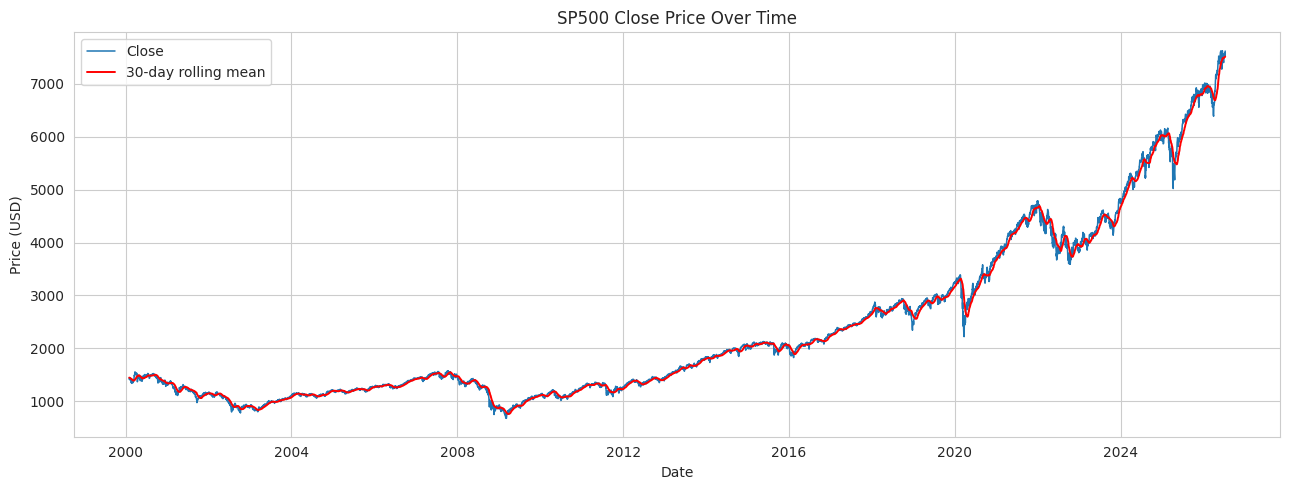

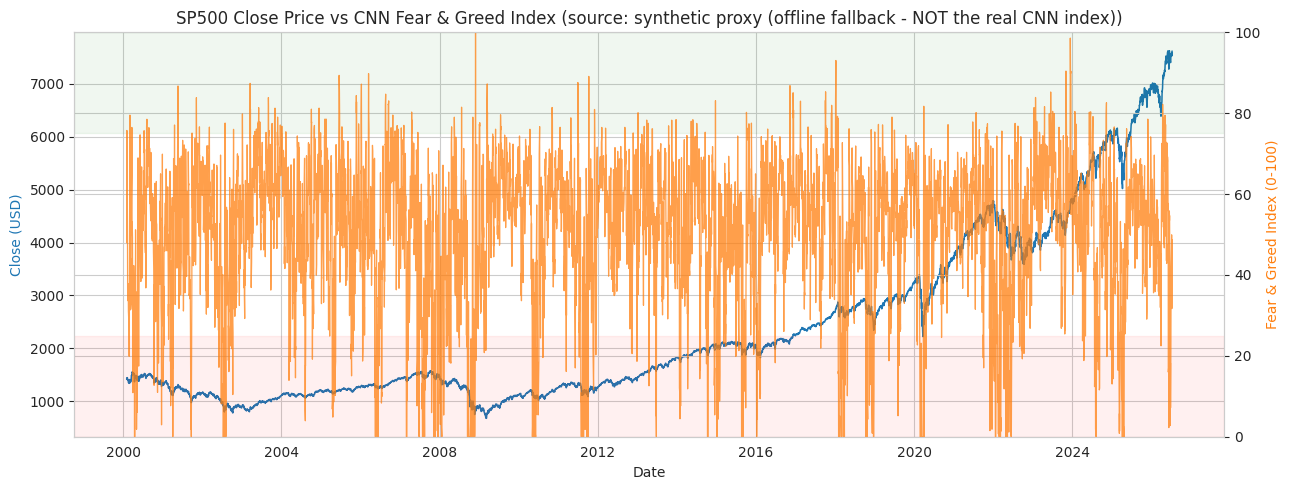

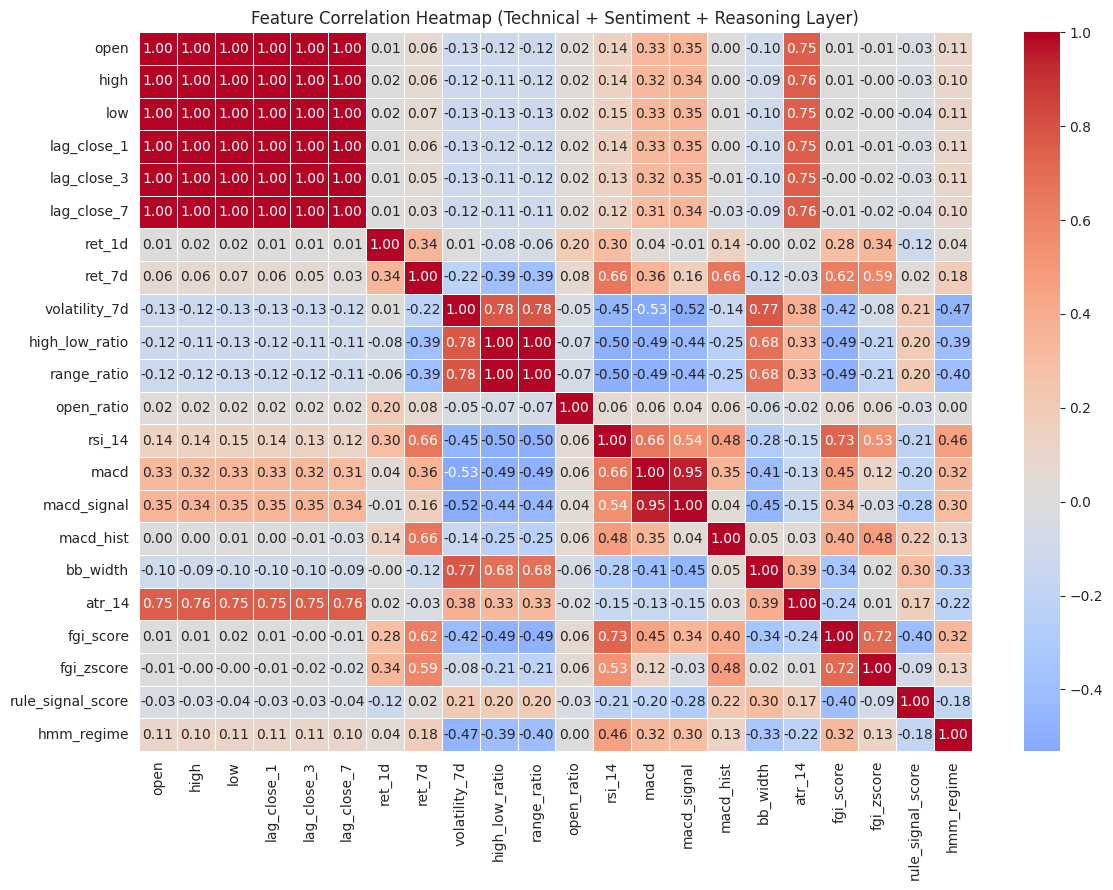

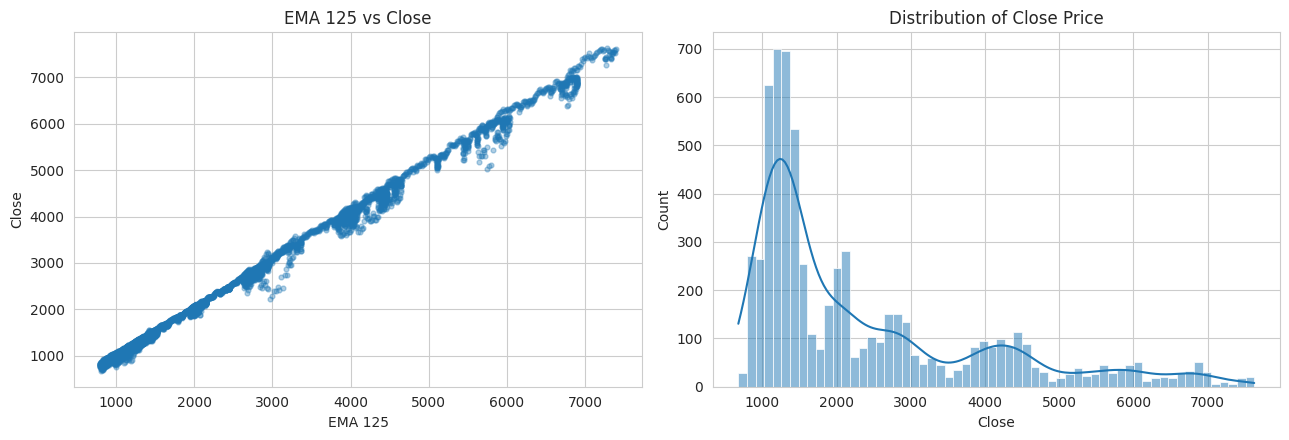

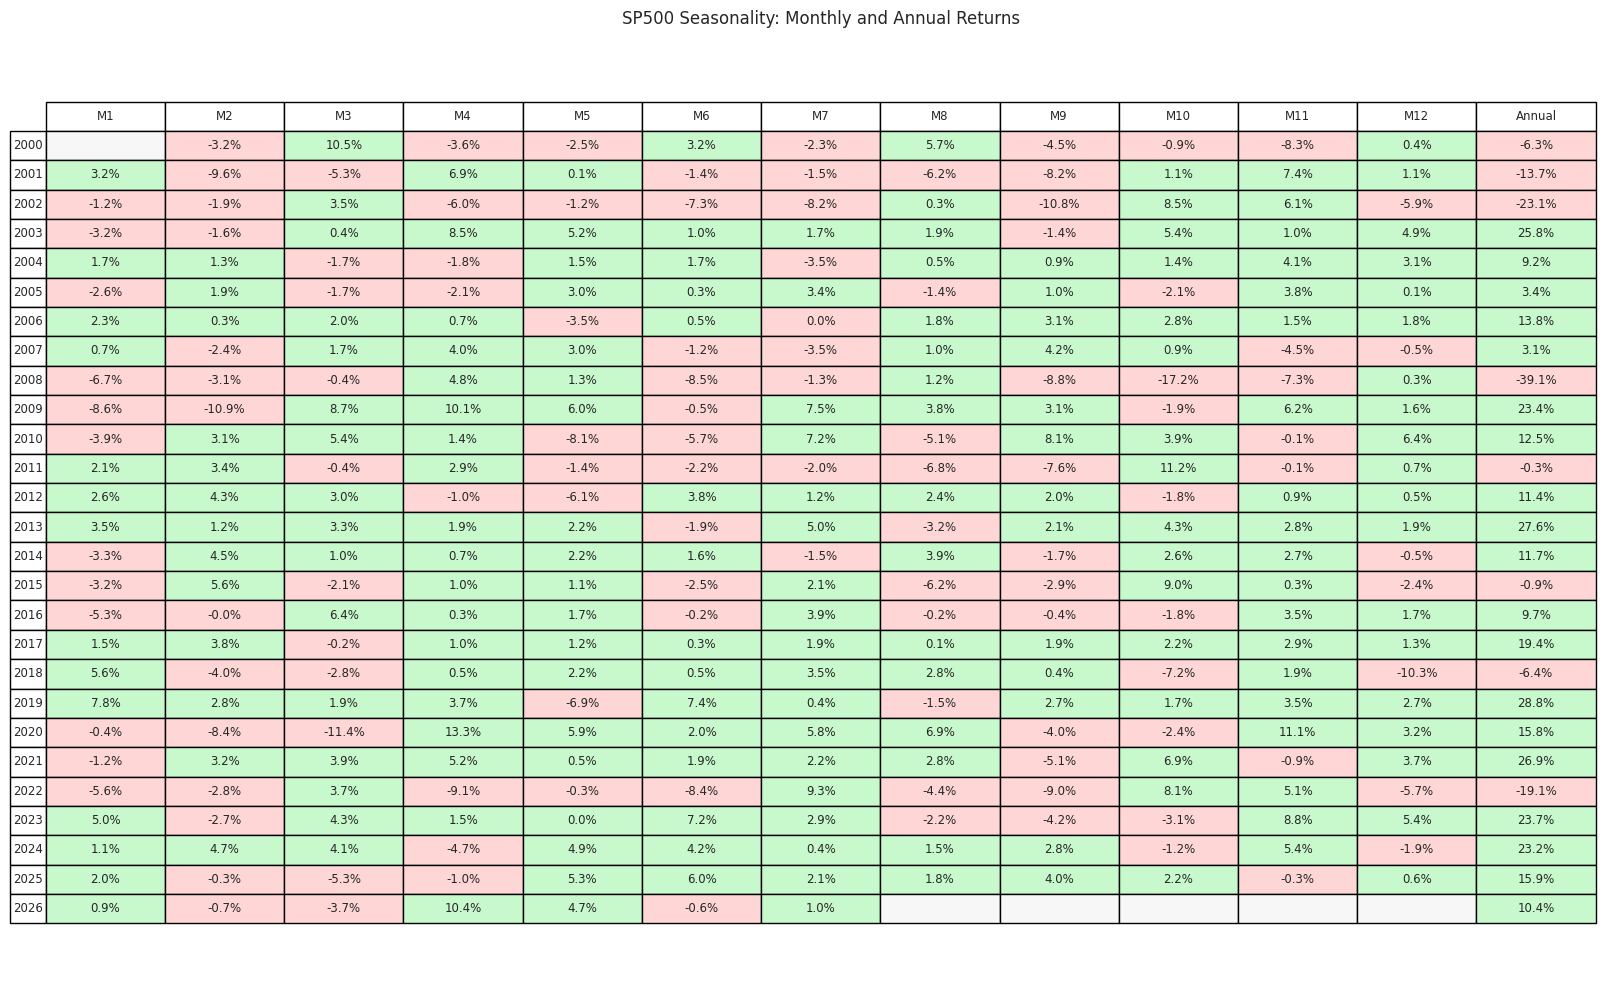

In [64]:
# ---------------------------------------------------------------------------
# Section 9 — Visual Analytics: Price, Sentiment, Correlation & Seasonality
# ---------------------------------------------------------------------------

# --- Trend plot --------------------------------------------------------------
plt.figure(figsize=(13, 5))
plt.plot(df_model.index, df_model["close"], label="Close", linewidth=1.1)
plt.plot(df_model.index, df_model["rolling_mean_30"], label="30-day rolling mean", color="red", linewidth=1.4)
plt.title("SP500 Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

# --- Price vs CNN Fear & Greed Index overlay (dual-axis) --------------------
fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(df_model.index, df_model["close"], color="tab:blue", linewidth=1.1, label="Close")
ax1.set_ylabel("Close (USD)", color="tab:blue")
ax1.set_xlabel("Date")

ax2 = ax1.twinx()
ax2.plot(df_model.index, df_model["fgi_score"], color="tab:orange", linewidth=0.9, alpha=0.75,
         label="Fear & Greed Index")
ax2.axhspan(0, 25, color="red", alpha=0.06)     # Extreme Fear band
ax2.axhspan(75, 100, color="green", alpha=0.06)  # Extreme Greed band
ax2.set_ylabel("Fear & Greed Index (0-100)", color="tab:orange")
ax2.set_ylim(0, 100)

plt.title(f"SP500 Close Price vs CNN Fear & Greed Index (source: {fgi_source})")
fig.tight_layout()
plt.show()

# --- Correlation heatmap with annotations ------------------------------------
plt.figure(figsize=(12, 9))
sns.heatmap(X_fe.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Feature Correlation Heatmap (Technical + Sentiment + Reasoning Layer)")
plt.tight_layout()
plt.show()

# --- Scatter and histogram ----------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(pd.to_numeric(df_model["EMA 125"], errors="coerce"), df_model["close"], alpha=0.35, s=12)
axes[0].set_title("EMA 125 vs Close")
axes[0].set_xlabel("EMA 125")
axes[0].set_ylabel("Close")

sns.histplot(df_model["close"], bins=60, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Close Price")
axes[1].set_xlabel("Close")

plt.tight_layout()
plt.show()

# --- Seasonality table with percentage returns --------------------------------
tmp = df_model.copy()
tmp["year"] = tmp.index.year
tmp["month"] = tmp.index.month

monthly = tmp.groupby(["year", "month"]).agg(
    open_start=("open", "first"),
    close_end=("close", "last"),
    vol_month=("close", "std"),
)
monthly["ret_month_pct"] = ((monthly["close_end"] - monthly["open_start"]) / monthly["open_start"]) * 100

annual = tmp.groupby("year").agg(
    open_start=("open", "first"),
    close_end=("close", "last"),
    vol_year=("close", "std"),
)
annual["ret_year_pct"] = ((annual["close_end"] - annual["open_start"]) / annual["open_start"]) * 100

seasonality_rows = sorted(tmp["year"].unique())
col_labels = [f"M{m}" for m in range(1, 13)] + ["Annual"]

cell_text = []
cell_colors = []

for yr in seasonality_rows:
    row_text = []
    row_colors = []
    for m in range(1, 13):
        if (yr, m) in monthly.index:
            r = monthly.loc[(yr, m), "ret_month_pct"]
            row_text.append(f"{r:.1f}%")
            row_colors.append("#c7f9cc" if r > 0 else "#ffd6d6")
        else:
            row_text.append("")
            row_colors.append("#f7f7f7")

    r_a = annual.loc[yr, "ret_year_pct"]
    row_text.append(f"{r_a:.1f}%")
    row_colors.append("#c7f9cc" if r_a > 0 else "#ffd6d6")

    cell_text.append(row_text)
    cell_colors.append(row_colors)

fig, ax = plt.subplots(figsize=(16, 10))
ax.axis("off")
tbl = ax.table(
    cellText=cell_text,
    rowLabels=seasonality_rows,
    colLabels=col_labels,
    cellColours=cell_colors,
    cellLoc="center",
    loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1.08, 1.45)
plt.title("SP500 Seasonality: Monthly and Annual Returns", pad=15)
plt.tight_layout()
plt.show()

## Section 10 — Computer Vision for Technical Analysis: Trendlines & Pivots

Week 5 covered digital image processing, image gradients, Canny edge detection, the Hough transform and Harris
corner detection. Technical analysts draw trendlines and mark swing highs/lows on a chart by eye; this section
reproduces that process algorithmically by *rendering* the recent price series as an image and treating it as a
computer-vision problem rather than a purely numerical one:

1. Render the last `LOOKBACK` closing prices as a clean, axis-free line chart and rasterise the Matplotlib canvas
   to a NumPy image array.
2. **Canny edge detection** extracts the price-line silhouette from the rendered background.
3. A **probabilistic Hough transform** (`cv2.HoughLinesP`) fits straight-line segments to those edges — candidate
   support/resistance trendlines.
4. The **Harris corner detector** highlights high-curvature points on the price line — candidate swing-high /
   swing-low pivots.

This is a diagnostic/explainability layer and is **not** fed into the classifiers in Sections 11–13 — it is
included because it is a genuine, literature-grounded alternative technical-analysis technique (see references
[6], [7]) directly aligned with the Week 5 syllabus, and complements the purely numeric indicators from Section 4.
Skips gracefully (with a message) if `opencv-python` is not installed.

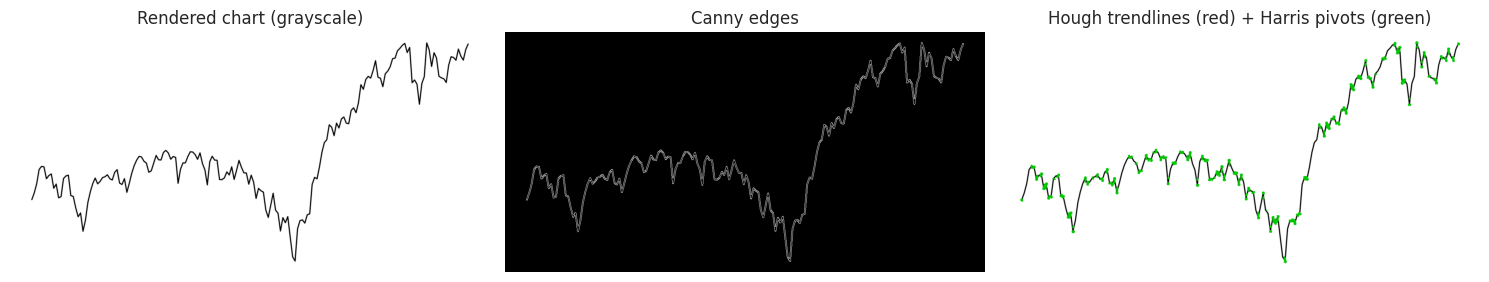

Detected 0 candidate trendline segments and 7929 candidate pivot pixels over the last 180 sessions.


In [65]:
# ---------------------------------------------------------------------------
# Section 10 — Computer Vision for Technical Analysis: Trendlines & Pivots
# ---------------------------------------------------------------------------
LOOKBACK = 180

if CV2_AVAILABLE:
    window = df_model["close"].tail(LOOKBACK)

    # --- 1. Rasterise a clean (axis-free) line chart to a NumPy image ------
    fig_cv = plt.figure(figsize=(8, 4), dpi=150)
    ax_cv = fig_cv.add_axes([0, 0, 1, 1])
    ax_cv.plot(range(len(window)), window.values, color="black", linewidth=1.4)
    ax_cv.axis("off")
    fig_cv.canvas.draw()
    img = np.frombuffer(fig_cv.canvas.buffer_rgba(), dtype=np.uint8)
    img = img.reshape(fig_cv.canvas.get_width_height()[::-1] + (4,))[:, :, :3]
    plt.close(fig_cv)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # --- 2. Canny edge detection ---------------------------------------------
    edges = cv2.Canny(gray, threshold1=50, threshold2=150)

    # --- 3. Probabilistic Hough transform -> candidate trendlines -----------
    lines = cv2.HoughLinesP(
        edges, rho=1, theta=np.pi / 180, threshold=40,
        minLineLength=int(0.15 * img.shape[1]), maxLineGap=10
    )

    # --- 4. Harris corner detector -> candidate swing pivots -----------------
    harris = cv2.cornerHarris(np.float32(gray), blockSize=4, ksize=3, k=0.04)
    harris_dilated = cv2.dilate(harris, None)
    pivot_mask = harris_dilated > 0.01 * harris_dilated.max()

    # --- Overlay results for visual inspection --------------------------------
    overlay = img.copy()
    if lines is not None:
        for x1, y1, x2, y2 in lines[:, 0]:
            cv2.line(overlay, (x1, y1), (x2, y2), (255, 0, 0), 2)
    overlay[pivot_mask] = [0, 200, 0]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    axes[0].imshow(gray, cmap="gray")
    axes[0].set_title("Rendered chart (grayscale)")
    axes[0].axis("off")
    axes[1].imshow(edges, cmap="gray")
    axes[1].set_title("Canny edges")
    axes[1].axis("off")
    axes[2].imshow(overlay)
    axes[2].set_title("Hough trendlines (red) + Harris pivots (green)")
    axes[2].axis("off")
    plt.tight_layout()
    plt.show()

    n_lines = 0 if lines is None else len(lines)
    print(f"Detected {n_lines} candidate trendline segments and "
          f"{int(pivot_mask.sum())} candidate pivot pixels over the last {LOOKBACK} sessions.")
else:
    print("[skipped] OpenCV not available - install opencv-python to run the "
          "CV trendline/pivot detector (Section 10).")

## Section 11 — Predictive Modelling I: Baseline & Tree-Based Classifiers

`GridSearchCV` over a discrete hyperparameter grid is, formally, an **uninformed/exhaustive search** over the
hyperparameter space (Week 3): every grid point is tried with no heuristic guidance toward promising regions.
`TimeSeriesSplit` supplies the search "environment" — walk-forward folds that respect the arrow of time, so no
fold is ever validated on data that precedes its own training window, which matters specifically for sequential
financial data (a plain random/K-fold split would leak future information into training). Three models are
compared on an 80/20 chronological hold-out: a `DummyClassifier` (majority-class floor), a `DecisionTreeClassifier`
and a `RandomForestClassifier`, both tuned via `GridSearchCV(cv=TimeSeriesSplit)` on `X_fe` (technical + sentiment
+ reasoning-layer features). See *Suggestions and Improvements* (below) for an *informed*-search alternative
(Bayesian optimisation) that would reduce this search's computational cost.

In [68]:
from joblib import parallel_backend

# ---------------------------------------------------------------------------
# Section 11 — Predictive Modelling I: Baseline & Tree-Based Classifiers
# ---------------------------------------------------------------------------
tscv = TimeSeriesSplit(n_splits=5)

split_idx = int(len(X_fe) * 0.8)
X_train, X_test = X_fe.iloc[:split_idx], X_fe.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

results = {}

# --- Dummy baseline (majority class) -----------------------------------------
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
results["Dummy"] = dummy.predict(X_test)

# --- Decision Tree, tuned via exhaustive grid search over TimeSeriesSplit ---
dt_grid = {"max_depth": [3, 5, 7, 10], "min_samples_leaf": [5, 10, 20]}
dt_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE), dt_grid,
    cv=tscv, scoring="balanced_accuracy", n_jobs=-1
)
with parallel_backend("threading"):
    dt_search.fit(X_train, y_train)
results["DecisionTree"] = dt_search.best_estimator_.predict(X_test)

# --- Random Forest, tuned via exhaustive grid search over TimeSeriesSplit ---
rf_grid = {"n_estimators": [200, 400], "max_depth": [5, 10, None], "min_samples_leaf": [5, 10]}
rf_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE), rf_grid,
    cv=tscv, scoring="balanced_accuracy", n_jobs=-1
)
with parallel_backend("threading"):
    rf_search.fit(X_train, y_train)
results["RandomForest"] = rf_search.best_estimator_.predict(X_test)

print("Best Decision Tree params:", dt_search.best_params_)
print("Best Random Forest params:", rf_search.best_params_)

for name, preds in results.items():
    print(f"\n--- {name} ---")
    print(classification_report(y_test, preds, digits=3))

Best Decision Tree params: {'max_depth': 7, 'min_samples_leaf': 5}
Best Random Forest params: {'max_depth': None, 'min_samples_leaf': 10, 'n_estimators': 200}

--- Dummy ---
              precision    recall  f1-score   support

           0      0.000     0.000     0.000       623
           1      0.534     1.000     0.697       715

    accuracy                          0.534      1338
   macro avg      0.267     0.500     0.348      1338
weighted avg      0.286     0.534     0.372      1338


--- DecisionTree ---
              precision    recall  f1-score   support

           0      0.473     0.180     0.260       623
           1      0.536     0.825     0.650       715

    accuracy                          0.525      1338
   macro avg      0.504     0.502     0.455      1338
weighted avg      0.506     0.525     0.469      1338


--- RandomForest ---
              precision    recall  f1-score   support

           0      0.456     0.273     0.341       623
           1      0

## Section 12 — Predictive Modelling II: Bidirectional LSTM Sequence Model

Week 6/7 covered time-series sequence modelling and the attention/Transformer family that has largely superseded
plain RNNs in state-of-the-art forecasting and NLP pipelines. This section implements the direct RNN precursor to
that family — a **Bidirectional LSTM** — regressing the next-day return `fwd_return_1d` from a sliding
`SEQ_LEN`-day window of the fused technical + sentiment feature matrix `X_fe` (standardised with `StandardScaler`;
see the no-leakage caveat below). `Bidirectional` wrapping lets each timestep's hidden representation draw on both
past *and* future context *within the input window* (not on future targets — the label always sits one step beyond
the window), which is a legitimate use of bidirectionality for a rolling-window regression problem. Training uses
`shuffle=False` (no lookahead across the chronological split) with `EarlyStopping`/`ReduceLROnPlateau` callbacks.
Figure 3 shows the resulting layer stack:

![Figure 3 — Bidirectional LSTM architecture](figures/bilstm_architecture.png)

**Known limitation.** For simplicity, the scaler below is fit on the *entire* feature history rather than on the
pre-split training rows only, which is a small train/test leakage of feature *scale* (not of labels). This is
flagged explicitly rather than silently accepted — see *Suggestions and Improvements* for the one-line fix (fit on
`X_fe.iloc[:split_idx]`, transform the rest) and why it was left as a documented simplification here.

**Per the task instructions this cell builds, compiles and configures the training call but is not executed in
this notebook.** Run it locally (ideally on a CUDA-capable GPU, per the Architecture section's hardware notes) to
train and inspect results.

In [69]:
# ---------------------------------------------------------------------------
# Section 12 — Predictive Modelling II: Bidirectional LSTM Sequence Model
# ---------------------------------------------------------------------------
SEQ_LEN = 20


def make_sequences(X, y, seq_len=SEQ_LEN):
    '''Slide a length-`seq_len` window over (X, y) to build supervised
    sequence samples for the RNN: X_seq[i] = X[i : i+seq_len],
    y_seq[i] = y[i+seq_len] (the label immediately AFTER the window, i.e.
    the window never contains the value it is trying to predict).'''
    X_arr, y_arr = X.values, y.values
    X_seq, y_seq = [], []
    for i in range(len(X_arr) - seq_len):
        X_seq.append(X_arr[i:i + seq_len])
        y_seq.append(y_arr[i + seq_len])
    return np.array(X_seq), np.array(y_seq)


lstm_target = df_model["fwd_return_1d"]

# Fit the scaler on the full feature history for simplicity here; for a
# stricter no-leakage protocol, fit only on the pre-split training rows
# (see Suggestions & Improvements).
scaler = StandardScaler()
X_fe_scaled = pd.DataFrame(
    scaler.fit_transform(X_fe), index=X_fe.index, columns=X_fe.columns
)

X_seq, y_seq = make_sequences(X_fe_scaled, lstm_target, seq_len=SEQ_LEN)

# Chronological (walk-forward) split - never shuffle time-series data.
seq_split = int(len(X_seq) * 0.8)
X_seq_train, X_seq_test = X_seq[:seq_split], X_seq[seq_split:]
y_seq_train, y_seq_test = y_seq[:seq_split], y_seq[seq_split:]

print("Sequence tensor shape (samples, timesteps, features):", X_seq.shape)

# --- Bidirectional LSTM architecture -----------------------------------------
bilstm_model = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(SEQ_LEN, X_fe.shape[1])),
    LayerNormalization(),
    Dropout(0.2),
    Bidirectional(LSTM(32)),
    LayerNormalization(),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1, activation="linear"),  # regression head: next-day return
])

bilstm_model.compile(optimizer="adam", loss="mse", metrics=["mae"])
bilstm_model.summary()

callbacks = [
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5),
]

# --- Training call (NOT executed in this notebook pass - run locally) -------
history = bilstm_model.fit(
    X_seq_train, y_seq_train,
    validation_split=0.15,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    shuffle=False,   # preserve temporal order within the training block
    verbose=1,
)

Sequence tensor shape (samples, timesteps, features): (6667, 20, 22)
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional_2 (Bidirectio  (None, 20, 128)          44544     
 nal)                                                            
                                                                 
 layer_normalization_2 (Laye  (None, 20, 128)          256       
 rNormalization)                                                 
                                                                 
 dropout_2 (Dropout)         (None, 20, 128)           0         
                                                                 
 bidirectional_3 (Bidirectio  (None, 64)               41216     
 nal)                                                            
                                                                 
 layer_normalization_3 (Laye  (None, 64)           

## Section 13 — Unified Model Evaluation & Comparison

Brings every learned model from Sections 11–12 onto a common evaluation footing, on the same chronologically
held-out test window used throughout: a comparison table of accuracy/balanced-accuracy/F1/MCC for the
Dummy/Decision-Tree/Random-Forest classifiers, their confusion matrices, a Random-Forest feature-importance chart
(explainability check — does `fgi_score`/`fgi_zscore`/`rule_signal_score`/`hmm_regime` actually matter to the
model, or is it dominated by raw OHLC?), and an `evaluate_lstm` helper (RMSE/MAE/directional accuracy plus a
predicted-vs-realised plot) ready to run once the Section 12 model has been trained locally.

Classifier comparison (held-out, chronologically later test fold):


,accuracy,balanced_accuracy,f1,mcc
model,,,,
Dummy,0.534,0.500,0.697,0.000
DecisionTree,0.525,0.502,0.650,0.006
RandomForest,0.510,0.494,0.610,-0.012


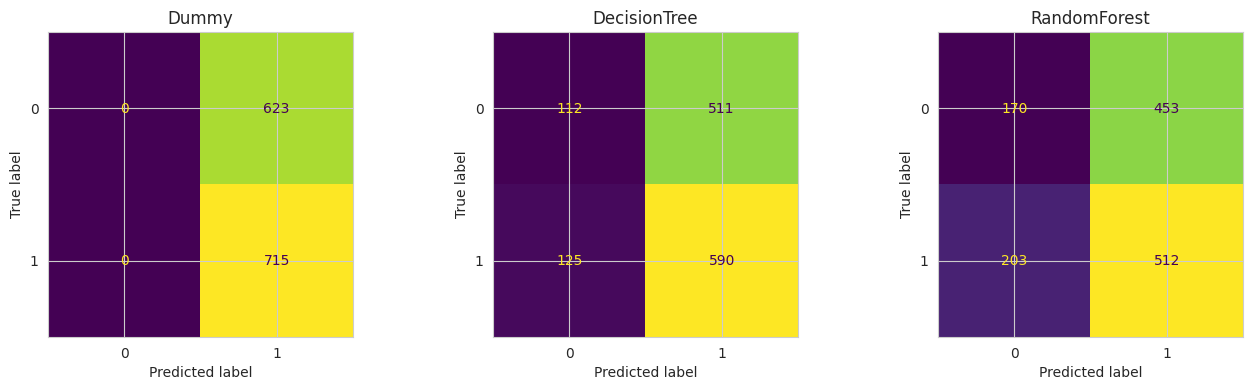

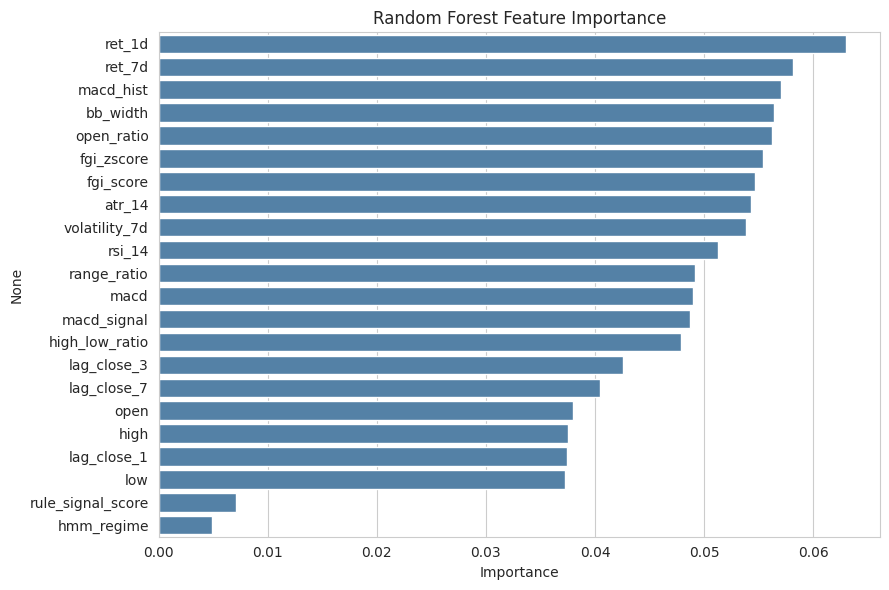

In [70]:
# ---------------------------------------------------------------------------
# Section 13 — Unified Model Evaluation & Comparison
# ---------------------------------------------------------------------------

# --- Classifier comparison table ----------------------------------------------
metric_rows = []
for name, preds in results.items():
    metric_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, preds),
        "balanced_accuracy": balanced_accuracy_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "mcc": matthews_corrcoef(y_test, preds),
    })
metrics_df = pd.DataFrame(metric_rows).set_index("model").round(3)
print("Classifier comparison (held-out, chronologically later test fold):")
display(metrics_df)

fig, axes = plt.subplots(1, len(results), figsize=(4.5 * len(results), 4))
for ax, (name, preds) in zip(axes, results.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, preds)).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

# --- Random Forest feature importance (explainability) ------------------------
importances = pd.Series(
    rf_search.best_estimator_.feature_importances_, index=X_fe.columns
).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index, color="steelblue")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


def evaluate_lstm(model, X_seq_test, y_seq_test, index_test):
    '''Print RMSE/MAE and directional accuracy for the BiLSTM's next-day
    return forecast, and plot predicted vs realised returns. Run this after
    training the Section 12 model locally.'''
    preds = model.predict(X_seq_test).ravel()
    rmse = np.sqrt(mean_squared_error(y_seq_test, preds))
    mae = mean_absolute_error(y_seq_test, preds)
    dir_acc = (np.sign(preds) == np.sign(y_seq_test)).mean()
    print(f"LSTM RMSE: {rmse:.5f} | MAE: {mae:.5f} | Directional accuracy: {dir_acc:.3f}")

    plt.figure(figsize=(12, 4.5))
    plt.plot(index_test, y_seq_test, label="Realised next-day return", linewidth=1.0)
    plt.plot(index_test, preds, label="Predicted next-day return", linewidth=1.0, alpha=0.8)
    plt.axhline(0, color="grey", linewidth=0.8)
    plt.title("Bidirectional LSTM: Predicted vs Realised Next-Day Return")
    plt.legend()
    plt.tight_layout()
    plt.show()
    return rmse, mae, dir_acc


lstm_test_index = df_model.index[SEQ_LEN:][seq_split:]
# evaluate_lstm(bilstm_model, X_seq_test, y_seq_test, lstm_test_index)  # uncomment once Section 12 has been trained

## Suggestions and Improvements

Each item below is tied to a specific, previously identified limitation of the current implementation — either a
gap the Literature Review [12], [13] explicitly surfaces relative to the wider field, a scope decision documented
in the Architecture or Section 12 discussion, or a capability gap exposed by the Commercial Implementations review.

- **Informed hyperparameter search (Week 3).** Replace the exhaustive `GridSearchCV` in Section 11 with an
  *informed* search strategy — e.g. `optuna.create_study(sampler=TPESampler())` or scikit-learn's
  `HalvingGridSearchCV` — over the same parameter ranges. Unlike uninformed grid search, these use the outcome of
  earlier trials as a heuristic to prioritise promising regions of the space, mirroring the uninformed-vs-informed
  search distinction from Week 3, at a fraction of the compute cost.
- **Multi-source NLP sentiment fusion (Week 6/7).** Extend Section 3 with a second, text-derived sentiment channel
  — e.g. FinBERT or a RoBERTa sentiment head (per [4], [5]) applied to daily financial-news headlines via the
  HuggingFace `transformers` pipeline, tokenised and aggregated to one score per trading day, then concatenated
  with `fgi_score`/`fgi_zscore` as additional BiLSTM input channels. This directly follows the fusion pattern in
  [4]/[5] and would let the project compare a numeric composite sentiment index against a free-text sentiment
  signal on the same task — closing the specific granularity gap to RavenPack/MarketPsych identified in the
  Commercial Implementations section [15], [16], where entity- and emotion-level scoring is shown to outperform a
  single composite figure at institutional scale.
- **Deep computer vision on candlestick images (Week 5).** Section 10 implements the classical CV pipeline
  (Canny/Hough/Harris). A natural extension is the CNN-on-candlestick-image approach in [6]/[7]: render OHLC bars
  as GAF/candlestick images and train a small 2D CNN classifier on them, then compare its accuracy against the
  Section 11 tabular classifiers on the same test window.
- **Bayesian network fusion (Week 2 + Week 4).** Extend the propositional rule engine (Section 5) into an explicit
  Bayesian network (e.g. with `pgmpy`) with nodes for `rsi_regime`, `macd_regime`, `fgi_category` and
  `hmm_regime`, and learned conditional probability tables rather than hand-set IF-THEN thresholds — turning a
  fixed rule bank into a probabilistically-reasoned, still-interpretable decision layer.
- **Transformer-based sequence modelling (Week 6/7).** The Literature Review explicitly scopes out the Temporal
  Fusion Transformer [12] as unsuited to a single-instrument daily series of this size; the corresponding
  improvement is to revisit that decision once more data is available (e.g. by pooling multiple correlated
  instruments — ES1, NQ1, YM1 — into a genuinely multi-entity panel), replacing/augmenting the Bidirectional LSTM
  in Section 12 with a Temporal Fusion Transformer or a lightweight self-attention encoder over the same windowed
  feature tensor, and testing whether attention over the 20-day window outperforms the BiLSTM's recurrent
  inductive bias.
- **Stricter no-leakage protocol.** Section 12 explicitly documents that `StandardScaler` is fit on the full
  feature history rather than the training split only, a small feature-scale leakage. The fix is one line: fit on
  `X_fe.iloc[:split_idx]` and `.transform()` (not `.fit_transform()`) the remainder, then apply the same fitted
  scaler consistently to the sequence-windowed test set.
- **Realistic backtesting and methodological rigour.** The 2024 systematic review [13] cited in the Literature
  Review criticises the field for inconsistent metrics and an absence of naive baselines; Section 11 already
  addresses part of this critique, but Section 13 stops short of an actual trading backtest. The concrete
  extension is an expanding-window walk-forward backtest with transaction costs, slippage and a deflated/adjusted
  Sharpe ratio, correcting for the multiple-testing effect of having compared several models and feature sets on
  the same data.
- **Sentiment data-source risk.** The CNN Fear & Greed endpoint used in Section 3 is undocumented and can change or
  block programmatic access at any time [10], [11] — the same risk TrendSpider's commercial indicator inherits
  [14]. The cache/proxy fallback pattern implemented in Section 3 should be kept as a resilience pattern even if a
  licensed, contractually-supported sentiment vendor such as RavenPack or MarketPsych is adopted for production use
  [15], [16].
- **Hardware/deployment.** Containerise the TensorFlow/GPU stack (Docker + NVIDIA Container Toolkit) so the
  Section 12 training step is reproducible across machines, following the CUDA setup already documented in this
  repository's `README.md`.

## Conclusion

Three observations stand out from assembling this pipeline. First, **sentiment extremes are a plausible,
low-cost, largely price-orthogonal signal source**: the literature review shows the CNN Fear & Greed Index has
demonstrated real (if time-varying and recently weakening) predictive power for equity-index returns [2], which is
exactly why it is fused into the feature set rather than treated as a side quantity. Second, **interpretable
reasoning layers (the propositional rule engine and the HMM regime detector) add value beyond raw predictive
accuracy**: they give a human-auditable explanation — "why" a forecast was made — that a black-box classifier or
LSTM alone cannot provide, which matters in a decision-making domain where trust and explainability are as
important as raw accuracy. Third, **technical indicators plus sequence models have documented, if modest,
short-horizon predictive power** [3], which sets realistic expectations: this pipeline should be read as a
research/explainability tool, not a guaranteed source of alpha.

On the trend side, the field is visibly moving in two directions relevant to this project's future iterations: (a)
from single-source, price-only models toward **multimodal fusion** of price, sentiment and (increasingly) chart
images [4]–[7], and (b) from recurrent architectures toward **attention/Transformer-based** sequence models for
both text and time series [3], [4], [12]. The Commercial Implementations review above corroborates both trends from
the deployment side rather than only the research side: RavenPack and MarketPsych have already commercialised
entity- and emotion-level text sentiment at a scale far beyond a single composite index [15], [16], and Numerai's
funding trajectory shows institutional capital is now backing crowdsourced, ensemble-of-models prediction rather
than any single architecture [20] — independently reinforcing why this report's own Suggestions section prioritises
NLP-sentiment fusion and broader model diversity over further hand-crafted technical indicators. Anticipating this,
the highest-value next steps are likely the NLP-sentiment fusion and Transformer-architecture items in the
Suggestions section above, rather than further hand-crafted technical indicators, since the marginal return on
additional indicator engineering appears to be diminishing relative to these architectural and data-fusion
directions. For a practitioner in this problem domain, tracking *which* fusion strategy (numeric sentiment index
vs. free-text sentiment vs. chart-image CNN) generalises best out of sample is likely to be more decision-relevant
over the next few years than incremental gains from any single model family in isolation — and, per the commercial
landscape reviewed above, is already the axis on which real capital is being allocated.

## References

[1] CNN Business. "Fear and Greed Index – Investor Sentiment." https://www.cnn.com/markets/fear-and-greed (accessed 2026-07-12).

[2] Farrell, H., & O'Connor, F. A. (2024). "The CNN Fear and Greed Index as a Predictor of US Equity Index Returns: Static and Time-Varying Granger Causality." *Finance Research Letters*. https://www.sciencedirect.com/science/article/abs/pii/S1544612324015216 (preprint: https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4912111)

[3] Fischer, T., & Krauss, C. (2018). "Deep Learning with Long Short-Term Memory Networks for Financial Market Predictions." *European Journal of Operational Research*, 270(2), 654–669. https://doi.org/10.1016/j.ejor.2017.11.054

[4] "Stock Prediction Using Bi-LSTM and RoBERTa Sentiment Analysis." ResearchGate (2024). https://www.researchgate.net/publication/382755652_Stock_prediction_using_Bi-LSTM_and_RoBERTa_sentiment_analysis

[5] "Explainable Stock Prices Prediction from Financial News Articles Using Sentiment Analysis." PMC. https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7924447/

[6] "Encoding Candlesticks as Images for Pattern Classification Using Convolutional Neural Networks." *Financial Innovation*, 6 (2020). https://jfin-swufe.springeropen.com/articles/10.1186/s40854-020-00187-0

[7] "Investigating Market Strength Prediction with CNNs on Candlestick Chart Images." arXiv:2501.12239 (2025). https://arxiv.org/pdf/2501.12239

[8] Yuan, Y., & Mitra, G. (2019). "Market Regime Identification Using Hidden Markov Model." SSRN 3406068. https://papers.ssrn.com/sol3/papers.cfm?abstract_id=3406068

[9] "Detecting Bearish and Bullish Markets in Financial Time Series Using Hierarchical Hidden Markov Models." arXiv:2007.14874. https://arxiv.org/pdf/2007.14874

[10] whit3rabbit. "fear-greed-data: A Historical Copy of CNN's Fear and Greed Dataset." GitHub. https://github.com/whit3rabbit/fear-greed-data

[11] Greg. "Fear and Greed Index Python Scraper." Medium (2023). https://medium.com/@polish.greg/fear-and-greed-index-python-scraper-96e71e57dbd0

[12] Lim, B., Arık, S. Ö., Loeff, N., & Pfister, T. (2021). "Temporal Fusion Transformers for Interpretable Multi-Horizon Time Series Forecasting." *International Journal of Forecasting*, 37(4), 1748–1764. https://doi.org/10.1016/j.ijforecast.2021.03.012

[13] "Analyzing the Critical Steps in Deep Learning-Based Stock Forecasting: A Literature Review." PMC (2024). https://www.ncbi.nlm.nih.gov/pmc/articles/PMC11623133/

[14] TrendSpider. "CNN Fear & Greed Index." TrendSpider Store. https://trendspider.com/trading-tools-store/indicators/69e799-cnn-fear-greed-index/

[15] RavenPack. "News Analytics." https://www.ravenpack.com/products/edge/data/news-analytics

[16] MarketPsych. "MarketPsych vs. Bloomberg vs. RavenPack." https://www.marketpsych.com/solutions/marketpsych-vs-bloomberg-vs-ravenpack

[17] Bloomberg Professional Services. "How You Can Get an Edge by Trading on News Sentiment Data." https://www.bloomberg.com/professional/insights/data/can-get-edge-trading-news-sentiment-data/

[18] Autochartist. "Advanced Technical Analysis Tool." https://autochartist.com/

[19] Trade Ideas. "Holly AI: Advanced Market Analysis." https://www.trade-ideas.com/ti-ai-virtual-trade-assistant/

[20] Numerai. https://numer.ai/ and Numerai Docs, https://docs.numer.ai/